In [2]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="someonecantcode-",
    # Set the wandb project where this run will be logged.
    project="my-awesome-project",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

acc,▁▆▇▇███▇
loss,█▄▂▁▁▂▁▁
acc,0.82024
loss,0.10501


In [3]:
import os
import torch
import lpips
from datasets import load_dataset
import torchvision.transforms.v2 as transforms
from vae import VAE

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)
torch.backends.cudnn.benchmark = True
os.environ["TORCHINDUCTOR_CACHE_DIR"] = ".inductor_cache"
# ------------------------------------------------------------
img_size = 256
batch_size = 8

dataset = load_dataset("arrow", data_files="../data/filtered/*.arrow")
transform = transforms.Compose(
    [
        transforms.Resize((img_size, img_size)),
        transforms.RGB(),
        transforms.ToTensor(),
    ]
)
def transform_batch(examples):
    images = [transform(img) for img in examples["jpg"] if img is not None]
    return {"pixel_values": images}

dataset = dataset.with_transform(transform_batch)
dataloader = torch.utils.data.DataLoader(dataset['train'], batch_size=batch_size, pin_memory=False)

# ------------------------------------------------------------
total_steps: int = 10
lr_cooldown_steps: int = 4000
lr = 5e-4
kl_beta = 0.5
fft_weight = 0.20
lpips_weight = 0.20
model = VAE(
    n_channels=3,
    latent_channels=[16, 32, 64, 64],
    z_channels=32,
    n_heads=8,
    resnet_blocks=2
).to(device).to(memory_format=torch.channels_last)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# ------------------------------------------------------------

lpips_loss_function = lpips.LPIPS(net='alex').to(device)
lpips_loss_function.requires_grad_(False)
lpips_loss_function.eval()

data_iter = iter(dataloader)


cuda


Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/33 [00:00<?, ?it/s]

/gscratch/stf/btea/conda/envs/myenv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/gscratch/stf/btea/conda/envs/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/gscratch/stf/btea/conda/envs/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /gscratch/stf/btea/conda/envs/myenv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


In [7]:
for step in range(0, total_steps + 1):
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        data = next(data_iter)['pixel_values'].to(device)
        _, loss, recon_loss, kl_loss, fft_loss = model(data, lpips_loss_function, beta=kl_beta, fft_weight=fft_weight)
    
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    if (total_steps - step) <= lr_cooldown_steps:
        lr = (15000-step)/3e7 # 5e-4 -> 3e-6 15k steps
        for param_group in optimizer.param_groups:
            param_group["lr"] = max(lr, 3e-6)
            
    optimizer.step()
    
    if step % 10 == 0:
        print(f"step: {step:5d} | loss: {loss.item():8.4f} | norm: {norm.item():8.4f} | lr: {lr:.6f}")
        print(f"recon_loss: {recon_loss.item():.4f} kl_loss: {kl_loss.item():.4f} fft_loss: {fft_loss.item():.4f}")
        
    if step % 1000 == 0:
        torch.save(model.state_dict(), "vae.pt")

step:     0 | loss:   0.7689 | norm:   1.0551 | lr: 0.000500
recon_loss: 0.1710 kl_loss: 0.0255 fft_loss: 0.7734
step:    10 | loss:   0.7684 | norm:   1.4003 | lr: 0.000500
recon_loss: 0.1963 kl_loss: 0.0194 fft_loss: 0.7403


In [13]:
import matplotlib.pyplot as plt
from einops import rearrange

@torch.no_grad()
def display(tensor):
    img = rearrange(tensor.to(torch.float32), "c h w -> h w c").cpu()
    plt.figure(figsize=(8, 8))
    plt.subplots_adjust(0, 0, 1, 1)
    plt.axis("off")
    plt.imshow(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.057373047..1.34375].


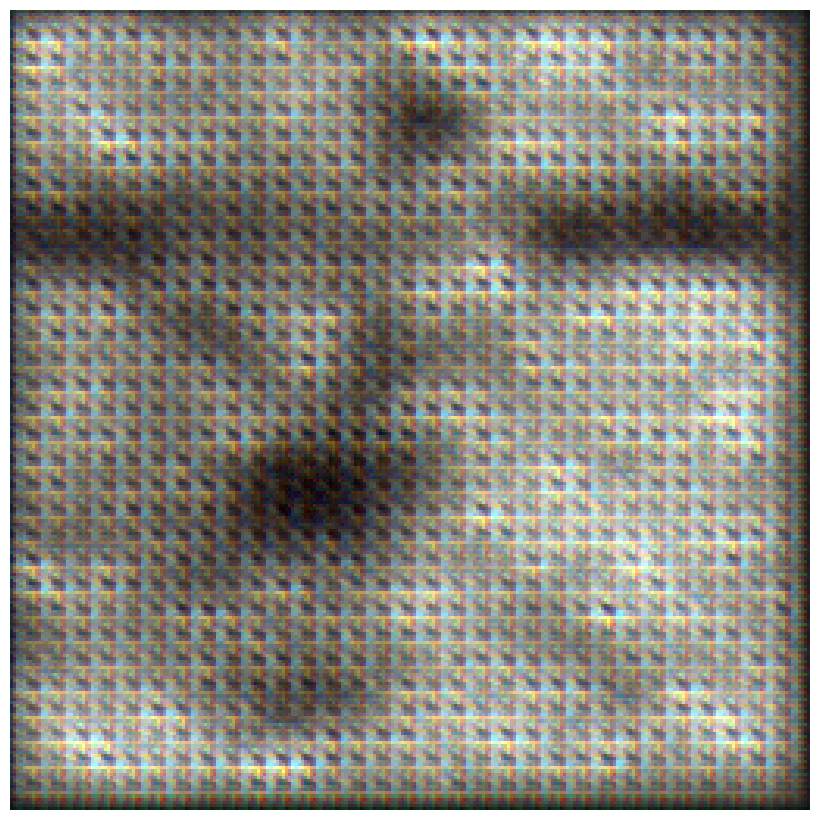

In [15]:
display(_[0])

VAE plan,

Use convolutional resnets to down sample and reconstruct. Bottle neck will use attention and some more convolutional resnets to return our mu and log var.

For loss, simply use L1 MAE reconstruction loss, simple DKL loss with latent to guassian distribution, and LPIPS loss.

Better models, use GANs?

Interesting: <https://arxiv.org/pdf/2605.13565>